# Helper functions and imports

In [52]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt


# =========================
# Helper: evaluation
# =========================
def evaluate(model, X_test, y_test, X_train, y_train, name="Model"):

    y_pred = model.predict(X_test)
    train_pred = model.predict(X_train)
    

    print(f"Train accuracy: {accuracy_score(y_train, train_pred)*100:.1f}%")
    print(f"Test accuracy:  {accuracy_score(y_test, y_pred)*100:.1f}%")

    # Evaluate
    print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.3f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred,
        target_names=['Low revenue', 'High revenue']))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                display_labels=['Low revenue', 'High revenue'])
    disp.plot(colorbar=False)
    plt.title(name)
    plt.tight_layout()
    plt.show()

# Default features

In [43]:
df = pd.read_csv('./datasets/cafe_sales_cleaned.csv')
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

daily = df.groupby(['Transaction Date', 'day_of_week', 'month', 'quarter', 'is_weekend'])['Total Spent'].sum().reset_index()
daily = daily.sort_values('Transaction Date').reset_index(drop=True)

# Creating lag features to inject temporal memory 

daily['revenue_lag_1']     = daily['Total Spent'].shift(1)
daily['revenue_lag_7']     = daily['Total Spent'].shift(7)
daily['revenue_rolling_7'] = daily['Total Spent'].rolling(7).mean()
daily = daily.dropna().reset_index(drop=True)

# Create the target variable and binary values 

median_revenue = daily['Total Spent'].median()
daily['revenue_class'] = (daily['Total Spent'] > median_revenue).astype(int)
print(f"Median daily revenue: £{median_revenue:.2f}")
print(f"Class distribution:\n{daily['revenue_class'].value_counts()}")

# Split into train and test periods to train the model 

train = daily[daily['Transaction Date'] < '2023-10-01']
test  = daily[daily['Transaction Date'] >= '2023-10-01']

features = ['day_of_week', 'month', 'quarter', 'is_weekend',
            'revenue_lag_1', 'revenue_lag_7', 'revenue_rolling_7']

X_train, y_train = train[features], train['revenue_class']
X_test,  y_test  = test[features],  test['revenue_class']

# Ensure fair coefficient estimation 

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

Median daily revenue: £230.75
Class distribution:
revenue_class
1    179
0    179
Name: count, dtype: int64


## Decision Tree

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Train accuracy: 68.8%
Test accuracy:  64.1%

Accuracy: 0.641

Classification Report:
              precision    recall  f1-score   support

 Low revenue       0.66      0.56      0.60        45
High revenue       0.63      0.72      0.67        47

    accuracy                           0.64        92
   macro avg       0.64      0.64      0.64        92
weighted avg       0.64      0.64      0.64        92



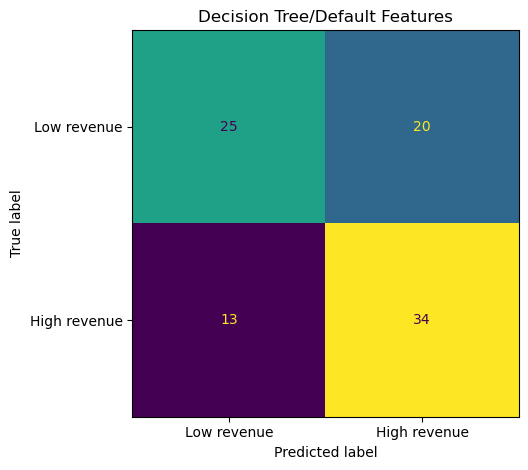

In [44]:
dt = DecisionTreeClassifier(random_state=42)

dt_params = {
    "max_depth": [None, 3, 5, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "criterion": ["entropy", "gini"]
}

dt_grid = GridSearchCV(
    dt,
    dt_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

dt_grid.fit(X_train, y_train)

evaluate(dt_grid.best_estimator_, X_test, y_test, X_train, y_train, "Decision Tree/Default Features")

## Random forest

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Train accuracy: 84.6%
Test accuracy:  63.0%

Accuracy: 0.630

Classification Report:
              precision    recall  f1-score   support

 Low revenue       0.64      0.56      0.60        45
High revenue       0.62      0.70      0.66        47

    accuracy                           0.63        92
   macro avg       0.63      0.63      0.63        92
weighted avg       0.63      0.63      0.63        92



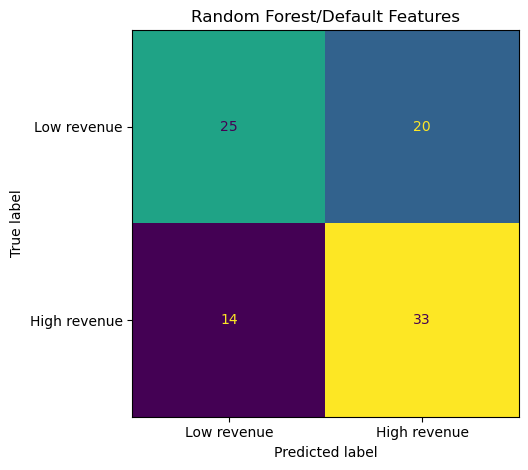

In [45]:
rf = RandomForestClassifier(random_state=42)

rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"]
}

rf_grid = GridSearchCV(
    rf,
    rf_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

evaluate(rf_grid.best_estimator_, X_test, y_test, X_train, y_train, "Random Forest/Default Features")

# Feature engineering

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

# Grouping by total spent daily 
df = pd.read_csv('./datasets/cafe_sales_cleaned.csv')
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

daily = df.groupby(['Transaction Date', 'day_of_week', 'month', 'quarter', 'is_weekend'])['Total Spent'].sum().reset_index()
daily = daily.sort_values('Transaction Date').reset_index(drop=True)

# New lag features 
daily['revenue_lag_1']      = daily['Total Spent'].shift(1)
daily['revenue_lag_7']      = daily['Total Spent'].shift(7)
daily['revenue_lag_14']     = daily['Total Spent'].shift(14)   # 2 week lag
daily['revenue_lag_30']     = daily['Total Spent'].shift(30)   # monthly lag

# Detecting trends over time 
daily['revenue_rolling_7']  = daily['Total Spent'].rolling(7).mean()
daily['revenue_rolling_14'] = daily['Total Spent'].rolling(14).mean()  # 2 week trend
daily['revenue_rolling_30'] = daily['Total Spent'].rolling(30).mean()  # monthly trend

# Predicts volatility and direction of change 

daily['revenue_std_7']      = daily['Total Spent'].rolling(7).std()    # how unstable revenue is
daily['revenue_std_14']     = daily['Total Spent'].rolling(14).std()   # 2 week volatility
daily['revenue_momentum']   = daily['Total Spent'].diff(7)             # change vs 7 days ago
daily['revenue_pct_change'] = daily['Total Spent'].pct_change(7)       # % change vs 7 days ago

# Day of the week feature create binary 
daily['is_monday']          = (daily['day_of_week'] == 0).astype(int)
daily['is_friday']          = (daily['day_of_week'] == 4).astype(int)
daily['is_saturday']        = (daily['day_of_week'] == 5).astype(int)
daily['is_sunday']          = (daily['day_of_week'] == 6).astype(int)

# SSeasonality features
daily['is_december']        = (daily['month'] == 12).astype(int)  # Christmas season
daily['is_summer']          = (daily['month'].isin([6, 7, 8])).astype(int)

daily = daily.dropna().reset_index(drop=True)

# Use the median to determine revenue class (higer, or lower than median)
median_revenue = daily['Total Spent'].median()
daily['revenue_class'] = (daily['Total Spent'] > median_revenue).astype(int)
print(f"Median daily revenue: £{median_revenue:.2f}")
print(f"Class distribution:\n{daily['revenue_class'].value_counts()}")

# Train and test split 
train = daily[daily['Transaction Date'] < '2023-10-01']
test  = daily[daily['Transaction Date'] >= '2023-10-01']

features = [
    # Original features
    'day_of_week', 'month', 'quarter', 'is_weekend',
    # Lag features
    'revenue_lag_1', 'revenue_lag_7', 'revenue_lag_14', 'revenue_lag_30',
    # Rolling averages
    'revenue_rolling_7', 'revenue_rolling_14', 'revenue_rolling_30',
    # Volatility and momentum
    'revenue_std_7', 'revenue_std_14', 'revenue_momentum', 'revenue_pct_change',
    # Day flags
    'is_monday', 'is_friday', 'is_saturday', 'is_sunday',
    # Season flags
    'is_december', 'is_summer'
]

X_train, y_train = train[features], train['revenue_class']
X_test,  y_test  = test[features],  test['revenue_class']

Median daily revenue: £230.50
Class distribution:
revenue_class
0    168
1    167
Name: count, dtype: int64


## Decision Tree

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Train accuracy: 98.8%
Test accuracy:  92.4%

Accuracy: 0.924

Classification Report:
              precision    recall  f1-score   support

 Low revenue       0.93      0.91      0.92        45
High revenue       0.92      0.94      0.93        47

    accuracy                           0.92        92
   macro avg       0.92      0.92      0.92        92
weighted avg       0.92      0.92      0.92        92



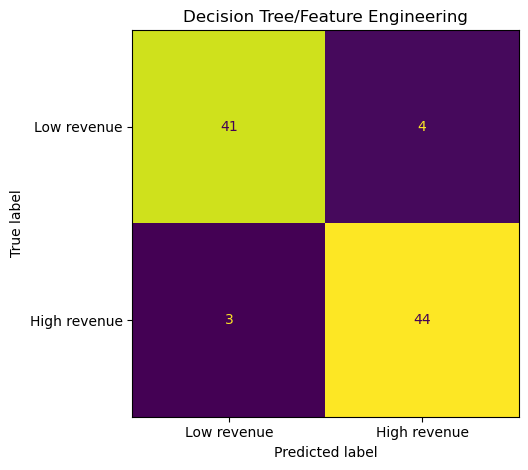

In [50]:
dt = DecisionTreeClassifier(random_state=42)

dt_params = {
    "max_depth": [None, 3, 5, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "criterion": ["entropy", "gini"]
}

dt_grid = GridSearchCV(
    dt,
    dt_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

dt_grid.fit(X_train, y_train)


evaluate(dt_grid.best_estimator_, X_test, y_test, X_train, y_train, "Decision Tree/Feature Engineering")

## Random forest

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Train accuracy: 100.0%
Test accuracy:  93.5%

Accuracy: 0.935

Classification Report:
              precision    recall  f1-score   support

 Low revenue       0.91      0.96      0.93        45
High revenue       0.96      0.91      0.93        47

    accuracy                           0.93        92
   macro avg       0.94      0.94      0.93        92
weighted avg       0.94      0.93      0.93        92



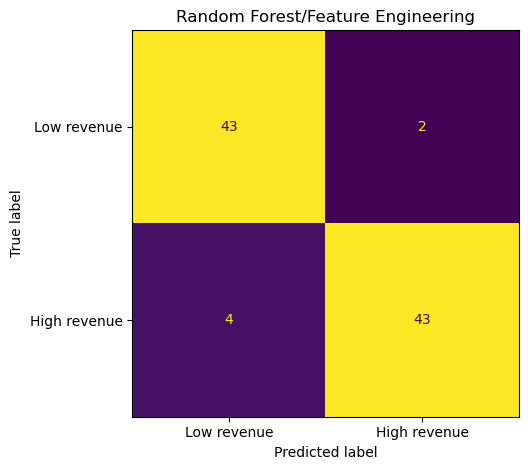

In [51]:
rf = RandomForestClassifier(random_state=42)

rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"]
}

rf_grid = GridSearchCV(
    rf,
    rf_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

evaluate(rf_grid.best_estimator_, X_test, y_test, X_train, y_train, "Random Forest/Feature Engineering")